<a href="https://colab.research.google.com/github/jakubkowalski-data/Python-Google-Colab-/blob/main/Adult%20Income%20Statistical%20Analysis%20with%20Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd


url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'

column_names = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

df = pd.read_csv(url, header=None, names=column_names)

print("Adult dataset loaded successfully.")

Adult dataset loaded successfully.


In [ ]:
import numpy as np

print(f"Shape before cleaning: {df.shape}")

df = df.replace(r'^\s*\?\s*$', np.nan, regex=True)

df_cleaned = df.dropna().reset_index(drop=True)

df = df_cleaned

print(f"Shape after cleaning: {df.shape}")
print("\\nFirst 5 rows of cleaned data:")
display(df.head())

Shape before cleaning: (32561, 15)
Shape after cleaning: (30162, 15)
\nFirst 5 rows of cleaned data:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
age_stats_by_income = df.groupby('income')['age'].agg(['mean', 'std'])

print("Descriptive Statistics for Age by Income Category:")
display(age_stats_by_income)

Descriptive Statistics for Age by Income Category:


,mean,std
income,,
<=50K,36.60806,13.464631
>50K,43.95911,10.269633


In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numerical_cols].corr()

print("Pearson Correlation Matrix for Numerical Features:")
display(corr_matrix)

Pearson Correlation Matrix for Numerical Features:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076511,0.043526,0.080154,0.060165,0.101599
fnlwgt,-0.076511,1.000000,-0.044992,0.000422,-0.009750,-0.022886
education-num,0.043526,-0.044992,1.000000,0.124416,0.079646,0.152522
capital-gain,0.080154,0.000422,0.124416,1.000000,-0.032229,0.080432
capital-loss,0.060165,-0.009750,0.079646,-0.032229,1.000000,0.052417
hours-per-week,0.101599,-0.022886,0.152522,0.080432,0.052417,1.000000


/tmp/ipykernel_240/1139145231.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='income', y='age', data=df, palette='Set2', ax=ax2)


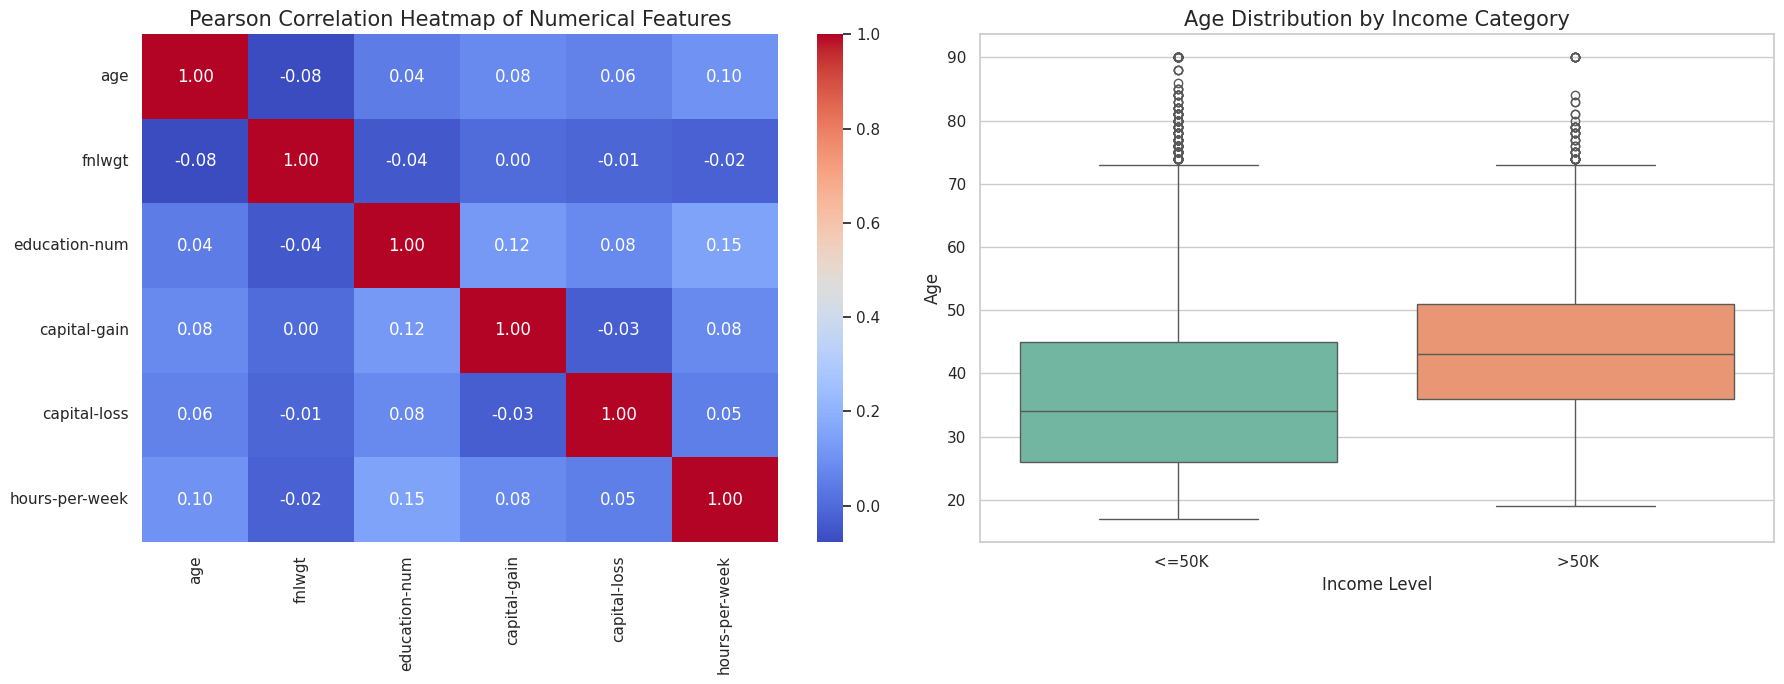

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', ax=ax1, cbar=True)
ax1.set_title('Pearson Correlation Heatmap of Numerical Features', fontsize=15)

sns.boxplot(x='income', y='age', data=df, palette='Set2', ax=ax2)
ax2.set_title('Age Distribution by Income Category', fontsize=15)
ax2.set_xlabel('Income Level', fontsize=12)
ax2.set_ylabel('Age', fontsize=12)

plt.tight_layout()
plt.show()

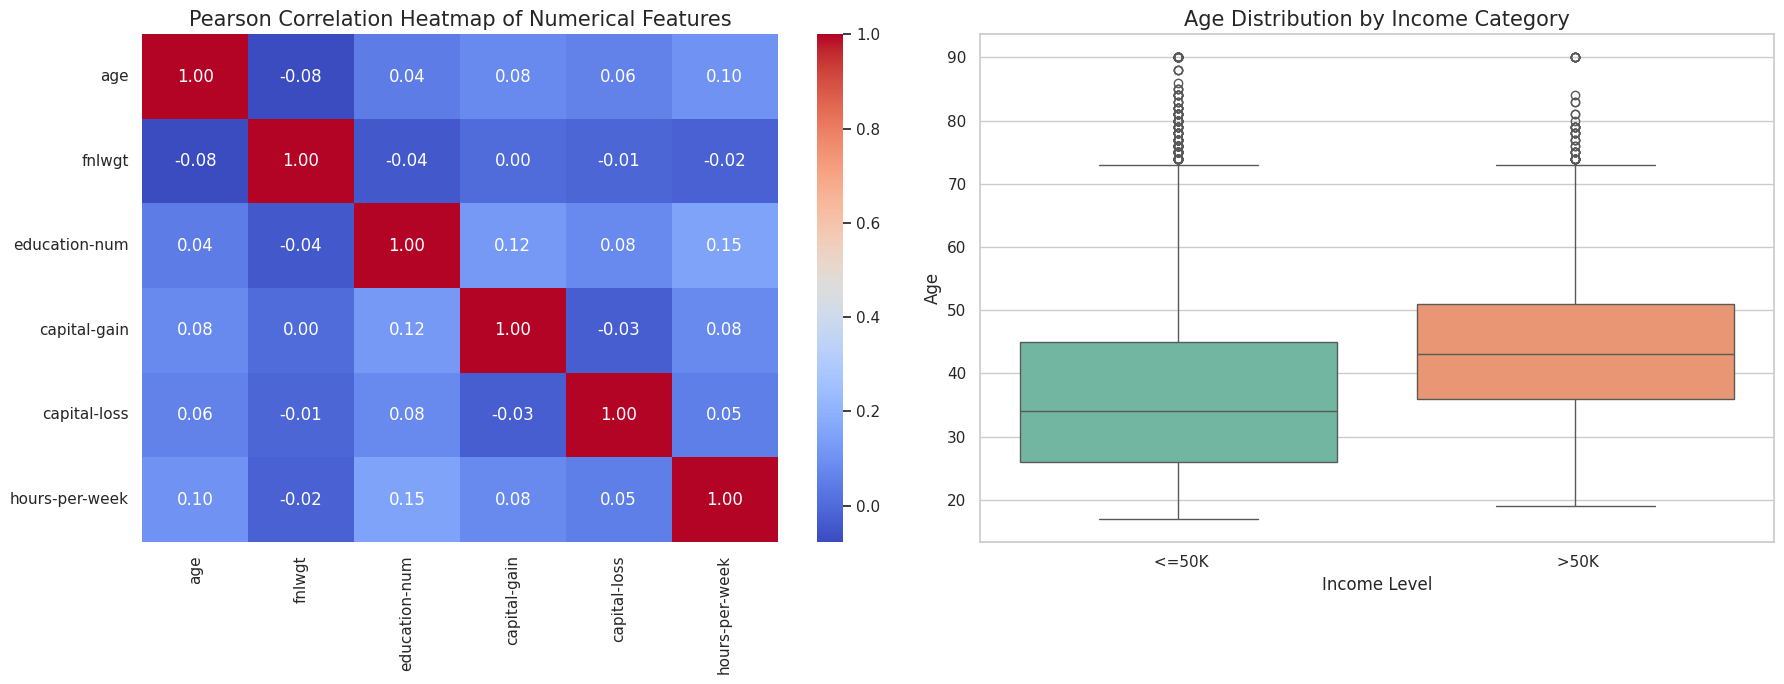

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', ax=ax1, cbar=True)
ax1.set_title('Pearson Correlation Heatmap of Numerical Features', fontsize=15)

sns.boxplot(x='income', y='age', data=df, hue='income', palette='Set2', ax=ax2, legend=False)
ax2.set_title('Age Distribution by Income Category', fontsize=15)
ax2.set_xlabel('Income Level', fontsize=12)
ax2.set_ylabel('Age', fontsize=12)

plt.tight_layout()
plt.show()